# CFP score regularization on the screws filtering dataset

This notebook is a compact regularization example for the CFP API. It trains two independent CFP layers on the same gray-level morphological target:

- `task_only`: minimizes only the reconstruction loss;
- `edge_regularized`: minimizes the same reconstruction loss plus `regularization_penalty(...)` from an `edge_score_monotonicity` regularizer.

The goal is not to produce a benchmark result. The goal is to show where regularization enters the training loop, how it is declared in a filter spec, and how it changes score-violation diagnostics.


## Setup

Resolve the local checkout, import the libraries, fix the random seed, and select the best available device.


In [1]:
#!pip install mtlearn

from pathlib import Path
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# Prefer the local build and local Python package when running inside the repo.
cwd = Path.cwd().resolve()
repo_root = next(
    (
        p
        for p in (cwd, *cwd.parents)
        if (p / "pyproject.toml").exists()
        and (p / "mtlearn" / "python" / "mtlearn").exists()
    ),
    cwd,
)
for candidate in [
    repo_root / "build" / "mtlearn" / "bindings",
    repo_root / "mtlearn" / "python",
]:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

import mtlearn
from mtlearn import morphology
from mtlearn.layers import ConnectedFilterPreprocessingLayer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
generator = torch.Generator(device="cpu").manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
pd.set_option("display.max_columns", 50)

print("repo_root:", repo_root)
print("device:", device)
print("mtlearn:", mtlearn.__file__)


repo_root: /Volumes/SSD/GitHub/mtlearn
device: mps
mtlearn: /Volumes/SSD/GitHub/mtlearn/mtlearn/python/mtlearn/__init__.py


## Experiment configuration

Both layers use the same max-tree, attributes, scorer, target, optimizer, and initialization. The only difference is the explicit `edge_score_monotonicity` regularizer attached to `edge_regularized`.


In [9]:
DATASET_NAME = "screws_segmentation"
NUM_ROWS = 256
NUM_COLS = 256
BATCH_SIZE = 8
OUTPUT_SCALE = 255.0

NUM_EPOCHS = 500
REPORT_EPOCHS = {1, 5, 10, 20, 40, 60, 100, 200, 300, 400, 500}
LEARNING_RATE = 0.04
WEIGHT_DECAY = 1e-7
GRAD_CLIP = 5.0
IDENTITY_P0 = 0.90
SCORE_SHARPNESS = 4.0
CLAMP_LOGIT = 12.0
EDGE_REGULARIZATION_WEIGHT = 0.1
PLOT_SAMPLES = 2

TREE_TYPE = morphology.TreeType.MAX_TREE
ATTRIBUTES = (
    morphology.AttributeType.AREA,
    morphology.AttributeType.LENGTH_MAJOR_AXIS,
    morphology.AttributeType.LENGTH_MINOR_AXIS,
    morphology.AttributeType.INERTIA,
    morphology.AttributeType.CIRCULARITY,
    morphology.AttributeType.GRAY_HEIGHT,
    morphology.AttributeType.RECTANGULARITY,
)

config = {
    "dataset": DATASET_NAME,
    "image_size": f"{NUM_ROWS}x{NUM_COLS}",
    "tree_type": TREE_TYPE.name,
    "attributes": [attribute.name for attribute in ATTRIBUTES],
    "regularizer_kind": "edge_score_monotonicity",
    "regularizer_weight": EDGE_REGULARIZATION_WEIGHT,
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
    "score_sharpness": SCORE_SHARPNESS,
    "identity_p0": IDENTITY_P0,
}
display(pd.DataFrame([config]))


,dataset,image_size,tree_type,attributes,regularizer_kind,regularizer_weight,learning_rate,num_epochs,score_sharpness,identity_p0
0,screws_segmentation,256x256,MAX_TREE,"[AREA, LENGTH_MAJOR_AXIS, LENGTH_MINOR_AXIS, I...",edge_score_monotonicity,0.1,0.04,500,4.0,0.9


## Dataset and morphological target

The dataset supplies an input image and a binary target mask. The training target used here is gray-level morphological: foreground pixels keep the quantized input gray level, while background pixels are set to the max-tree root level. This makes the target compatible with the `preserve_root` constraint.


screws_segmentation: already available at /Volumes/SSD/GitHub/mtlearn/dat/screws_segmentation
train/test: 34 15
sample: 07_in.jpg
root level: 0.1921568661928177
foreground fraction: 0.019744873046875


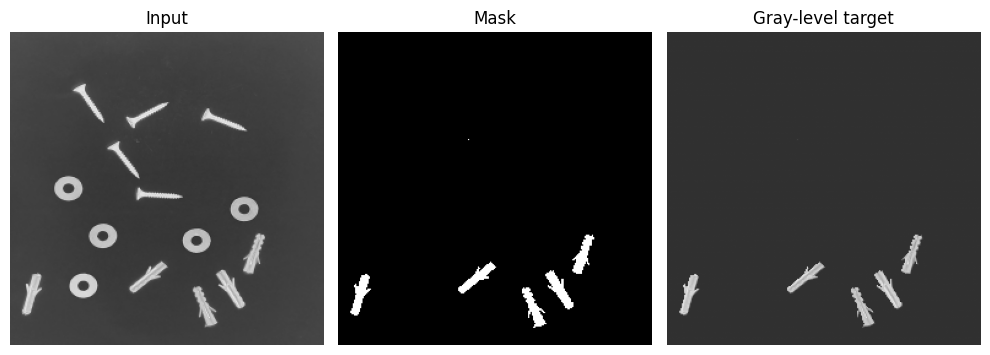

In [10]:
def input_as_tree_unit(x):
    """Match the quantized image scale used internally to build CFP trees."""
    x_u8 = (torch.clamp(x.detach(), 0.0, 1.0) * 255.0).to(torch.uint8)
    return x_u8.float().to(x.device) / 255.0


def morphological_target(x, mask):
    """Return the gray-level target, root level, and foreground mask."""
    x_tree = input_as_tree_unit(x)
    root = x_tree.flatten(2).amin(dim=2).view(x.shape[0], x.shape[1], 1, 1)
    foreground = mask > 0.5
    target = torch.where(foreground, x_tree, root)
    return target, root, foreground


dir_name = str(mtlearn.data.ensure_dataset(DATASET_NAME))
dataset = mtlearn.datasets.PairedImageDataset(
    root_dir=dir_name,
    grayscale_in=True,
    grayscale_target=True,
    invert_in=True,
    invert_target=True,
    num_rows=NUM_ROWS,
    num_cols=NUM_COLS,
    scale_in=True,
    scale_out=True,
    suffix_in="_in",
    suffix_target="_target",
)

trainset, testset = dataset.train_test_split(test_size=0.3, random_state=SEED)
trainset = list(trainset)
testset = list(testset)

cache_trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=False,
)
cache_testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=False,
)

x0, mask0, name0 = trainset[0]
target0, root0, foreground0 = morphological_target(x0.unsqueeze(0), mask0.unsqueeze(0))
print("train/test:", len(trainset), len(testset))
print("sample:", name0)
print("root level:", float(root0.squeeze()))
print("foreground fraction:", float(foreground0.float().mean()))

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(x0[0].detach().numpy(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Input")
axes[1].imshow(mask0[0].detach().numpy(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Mask")
axes[2].imshow(target0[0, 0].detach().numpy(), cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Gray-level target")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()


## CFP layers

The regularized layer uses the current registry-backed regularizer config. The unregularized layer has the same filter spec without the `regularizers` entry.


In [11]:
def make_filter_spec(name, *, regularizers=None):
    spec = {
        "name": name,
        "tree_type": TREE_TYPE,
        "attributes": ATTRIBUTES,
        "score_sharpness": SCORE_SHARPNESS,
        "constraints": [{"kind": "preserve_root"}],
    }
    if regularizers is not None:
        spec["regularizers"] = regularizers
    return spec


def make_layer(name, *, regularizers=None):
    return ConnectedFilterPreprocessingLayer(
        in_channels=1,
        filter_specs=[make_filter_spec(name, regularizers=regularizers)],
        scale_mode="dataset_clipped_zscore01",
        device=device,
        clamp=CLAMP_LOGIT,
    )


task_only = make_layer("task_only")
edge_regularized = make_layer(
    "edge_regularized",
    regularizers=[{"kind": "edge_score_monotonicity", "weight": EDGE_REGULARIZATION_WEIGHT}],
)
layers = {"task_only": task_only, "edge_regularized": edge_regularized}

for layer in layers.values():
    layer.init_identity(p0=IDENTITY_P0)

print("task_only regularizers:", task_only.get_config()["filter_specs"][0].get("regularizers", []))
print("edge_regularized regularizers:", edge_regularized.get_config()["filter_specs"][0].get("regularizers", []))
print("parameter contract:")
display(pd.DataFrame(edge_regularized.get_parameter_contract()["weights"]).T)


task_only regularizers: []
edge_regularized regularizers: [{'kind': 'edge_score_monotonicity', 'weight': 0.1}]
parameter contract:


,0
edge_regularized,7


## Cache trees and precompute targets

The CFP cached dataloaders assign stable sample indexes and precompute tree payloads. The supervised gray-level target is also materialized once so the training loop can focus on the CFP layers and the regularization term.


In [12]:
def build_layer_caches(layer, label):
    start = time.time()
    train_cached = layer.build_dataloader_cached(cache_trainloader)
    test_cached = layer.build_dataloader_cached_fixed_stats(
        cache_testloader,
        index_offset=len(trainset),
    )
    print(f"{label} cache time: {time.time() - start:.3f}s")
    return train_cached, test_cached


trainloader_cached, testloader_cached = build_layer_caches(task_only, "task_only")
_ = build_layer_caches(edge_regularized, "edge_regularized")


def unpack_model_input(model_input):
    if isinstance(model_input, (tuple, list)):
        return model_input[0], model_input[1]
    return model_input, None


@torch.no_grad()
def precompute_target_dataset(cached_loader, label):
    xs, idxs, targets, masks, roots = [], [], [], [], []
    start = time.time()
    for model_input, mask in cached_loader:
        x, idx = unpack_model_input(model_input)
        target, root, _ = morphological_target(x, mask)
        xs.append(x.detach().cpu())
        idxs.append(idx.detach().cpu().long())
        targets.append(target.detach().cpu())
        masks.append(mask.detach().cpu())
        roots.append(root.detach().cpu())

    result = torch.utils.data.TensorDataset(
        torch.cat(xs, dim=0),
        torch.cat(idxs, dim=0),
        torch.cat(targets, dim=0),
        torch.cat(masks, dim=0),
        torch.cat(roots, dim=0),
    )
    print(f"{label} target cache: {len(result)} samples in {time.time() - start:.3f}s")
    return result


train_target_dataset = precompute_target_dataset(trainloader_cached, "train")
test_target_dataset = precompute_target_dataset(testloader_cached, "test")

train_target_loader = torch.utils.data.DataLoader(
    train_target_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
)
eval_train_target_loader = torch.utils.data.DataLoader(
    train_target_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_target_loader = torch.utils.data.DataLoader(
    test_target_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
plot_target_loader = torch.utils.data.DataLoader(
    test_target_dataset,
    batch_size=min(PLOT_SAMPLES, len(test_target_dataset)),
    shuffle=False,
)


task_only cache time: 3.416s
edge_regularized cache time: 3.355s
train target cache: 34 samples in 0.006s
test target cache: 15 samples in 0.002s


## Metrics

The task metrics compare the reconstructed output to the gray-level target. The structural metrics inspect parent-child score inversions before multiplying by the regularizer weight.


In [13]:
def split_precomputed_batch(batch):
    x, idx, target, mask, root = batch
    x = x.to(device)
    target = target.to(device)
    mask = mask.to(device)
    root = root.to(device)
    return (x, idx), x, target, mask, root


def cfp_unit_output(layer, model_input):
    return layer(model_input) / OUTPUT_SCALE


@torch.no_grad()
def edge_violation_sums(layer, model_input):
    x, idx = unpack_model_input(model_input)
    if idx is None:
        raise ValueError("edge_violation_sums expects cached-loader input `(x, idx)`.")

    spec = layer.filter_specs[0]
    totals = {
        "edge_count": 0.0,
        "violation_count": 0.0,
        "violation_sum": 0.0,
        "violation_sq_sum": 0.0,
        "max_violation": 0.0,
    }

    for batch_index in range(x.shape[0]):
        for channel_index in range(x.shape[1]):
            base_key = f"{int(idx[batch_index])}_{channel_index}"
            info, norm_attrs = layer._get_tree_payload_for_sample(
                base_key,
                x[batch_index, channel_index],
                spec,
                {},
                use_cache=True,
            )
            context = layer._context_for(
                base_key,
                batch_index,
                channel_index,
                spec,
                mode="inspection",
            )
            scores = layer._score_nodes(spec, info, norm_attrs, layer._score_sharpness_for_spec(spec), context=context)
            parent = info["parent"].to(device=scores.device)
            node_ids = torch.arange(parent.numel(), device=scores.device)
            if "tpre" in info and "tpost" in info:
                alive = (info["tpost"] > info["tpre"]).to(device=scores.device)
                edge_mask = alive & alive[parent] & (parent != node_ids)
            else:
                edge_mask = parent != node_ids
            if not bool(edge_mask.any().item()):
                continue

            violations = torch.relu(scores[edge_mask] - scores[parent[edge_mask]])
            totals["edge_count"] += float(violations.numel())
            totals["violation_count"] += float((violations > 1e-6).sum())
            totals["violation_sum"] += float(violations.sum())
            totals["violation_sq_sum"] += float(violations.square().sum())
            totals["max_violation"] = max(totals["max_violation"], float(violations.max()))
    return totals


@torch.no_grad()
def evaluate(loader):
    for layer in layers.values():
        layer.eval()

    rows = []
    for name, layer in layers.items():
        sse = 0.0
        sae = 0.0
        pixel_count = 0.0
        regularization_sum = 0.0
        batch_count = 0
        edge_totals = {
            "edge_count": 0.0,
            "violation_count": 0.0,
            "violation_sum": 0.0,
            "violation_sq_sum": 0.0,
            "max_violation": 0.0,
        }

        for batch in loader:
            model_input, _, target, _, _ = split_precomputed_batch(batch)
            pred = cfp_unit_output(layer, model_input)
            err = pred - target
            sse += float(err.square().sum())
            sae += float(err.abs().sum())
            pixel_count += float(err.numel())
            regularization_sum += float(layer.regularization_penalty(model_input).detach().cpu())
            batch_count += 1

            batch_edges = edge_violation_sums(layer, model_input)
            for key in ("edge_count", "violation_count", "violation_sum", "violation_sq_sum"):
                edge_totals[key] += batch_edges[key]
            edge_totals["max_violation"] = max(edge_totals["max_violation"], batch_edges["max_violation"])

        rows.append(
            {
                "layer": name,
                "mse": sse / max(pixel_count, 1.0),
                "mae": sae / max(pixel_count, 1.0),
                "regularization_penalty": regularization_sum / max(batch_count, 1),
                "edge_violation_mean": edge_totals["violation_sum"] / max(edge_totals["edge_count"], 1.0),
                "edge_violation_mse": edge_totals["violation_sq_sum"] / max(edge_totals["edge_count"], 1.0),
                "edge_violation_rate": edge_totals["violation_count"] / max(edge_totals["edge_count"], 1.0),
                "max_edge_violation": edge_totals["max_violation"],
            }
        )
    return pd.DataFrame(rows)


initial_metrics = evaluate(eval_train_target_loader)
initial_metrics.insert(0, "epoch", 0)
initial_metrics.insert(1, "split", "train")
display(initial_metrics)


,epoch,split,layer,mse,mae,regularization_penalty,edge_violation_mean,edge_violation_mse,edge_violation_rate,max_edge_violation
0,0,train,task_only,0.013377,0.069108,0.0,0.0,0.0,0.0,0.0
1,0,train,edge_regularized,0.013377,0.069108,0.0,0.0,0.0,0.0,0.0


## Training

Each layer has its own optimizer. The regularized layer adds its own `regularization_penalty(...)` to the same mean-squared reconstruction loss. Images are shown only at the epochs listed in `REPORT_EPOCHS`.


epoch 1


,epoch,split,layer,mse,mae,regularization_penalty,edge_violation_mean,edge_violation_mse,edge_violation_rate,max_edge_violation
0,1,train,task_only,0.004403,0.016188,0.000000,0.079043,0.013929,0.798046,0.243372
1,1,train,edge_regularized,0.004403,0.016188,0.001392,0.079043,0.013928,0.798051,0.243372


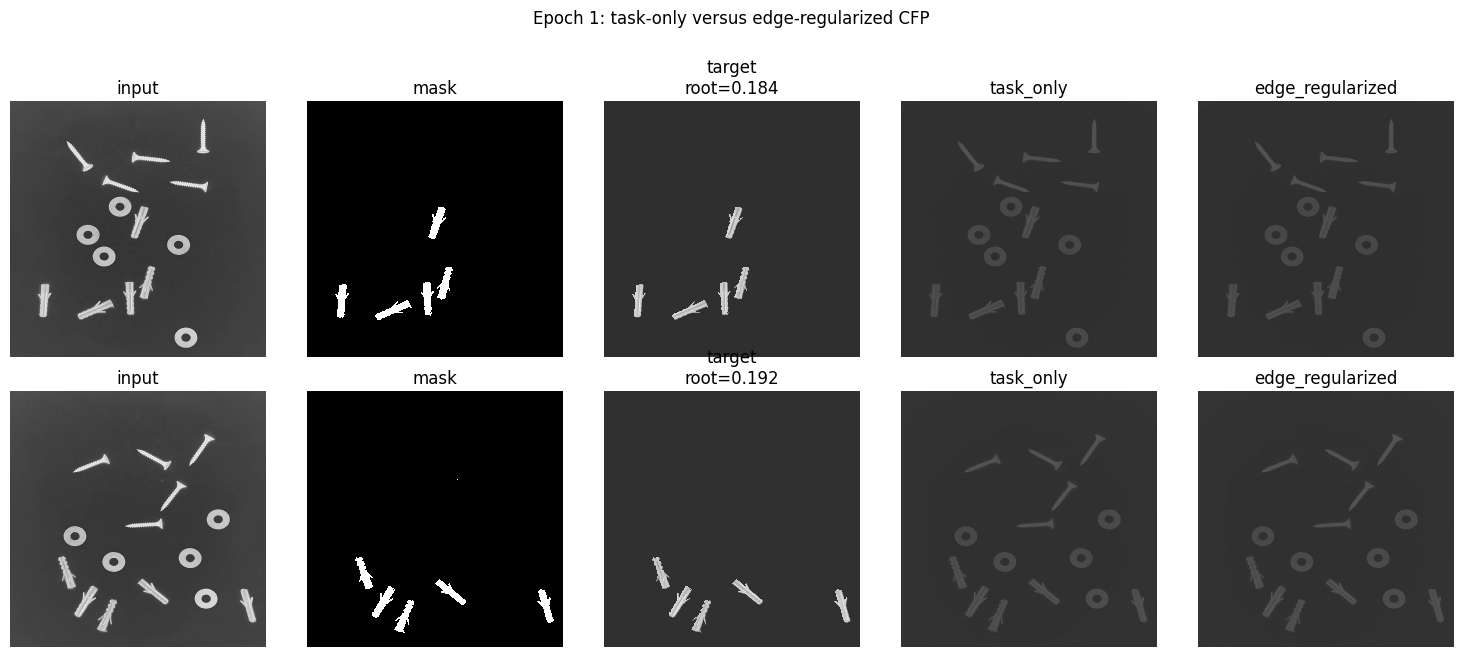

epoch 5


,epoch,split,layer,mse,mae,regularization_penalty,edge_violation_mean,edge_violation_mse,edge_violation_rate,max_edge_violation
0,5,train,task_only,0.003805,0.022935,0.000000,0.067104,0.014355,0.652582,0.371111
1,5,train,edge_regularized,0.003805,0.022936,0.001442,0.067102,0.014355,0.652576,0.371109


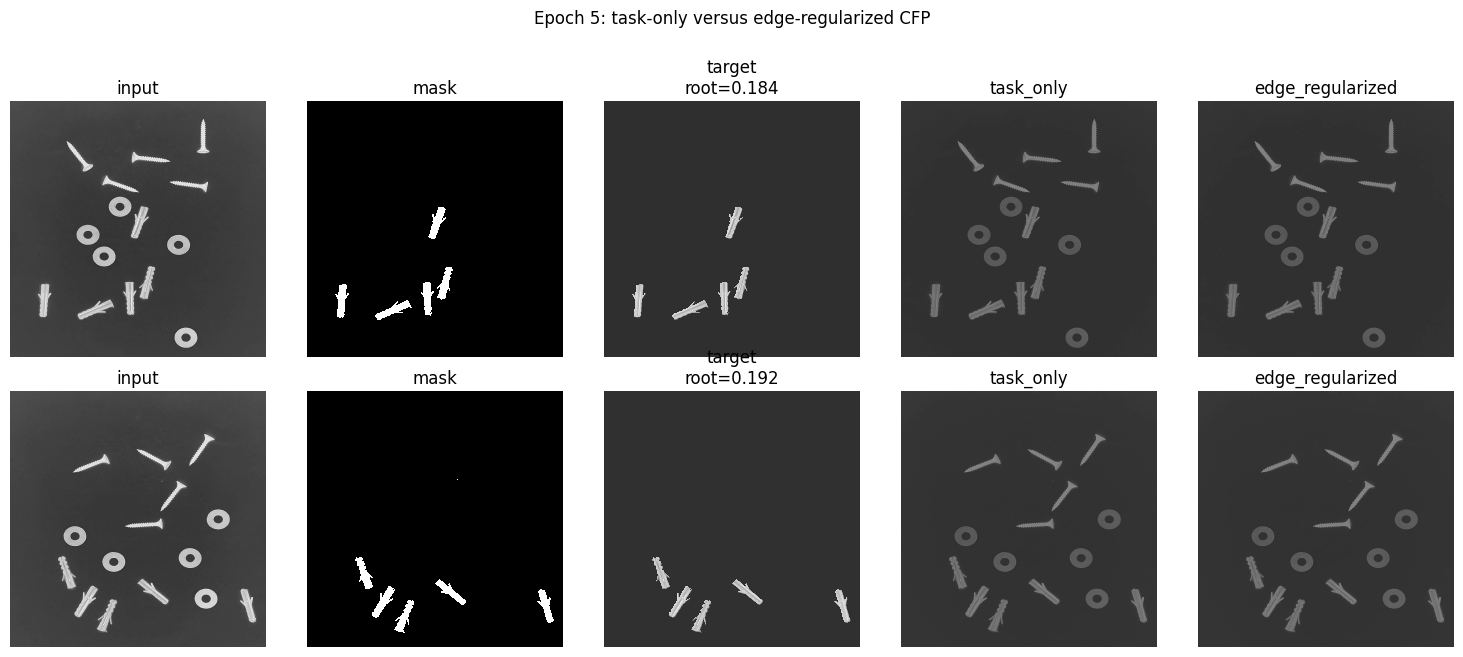

epoch 10


,epoch,split,layer,mse,mae,regularization_penalty,edge_violation_mean,edge_violation_mse,edge_violation_rate,max_edge_violation
0,10,train,task_only,0.003229,0.019348,0.000000,0.056309,0.013450,0.494389,0.481995
1,10,train,edge_regularized,0.003229,0.019348,0.001356,0.056306,0.013448,0.494372,0.481995


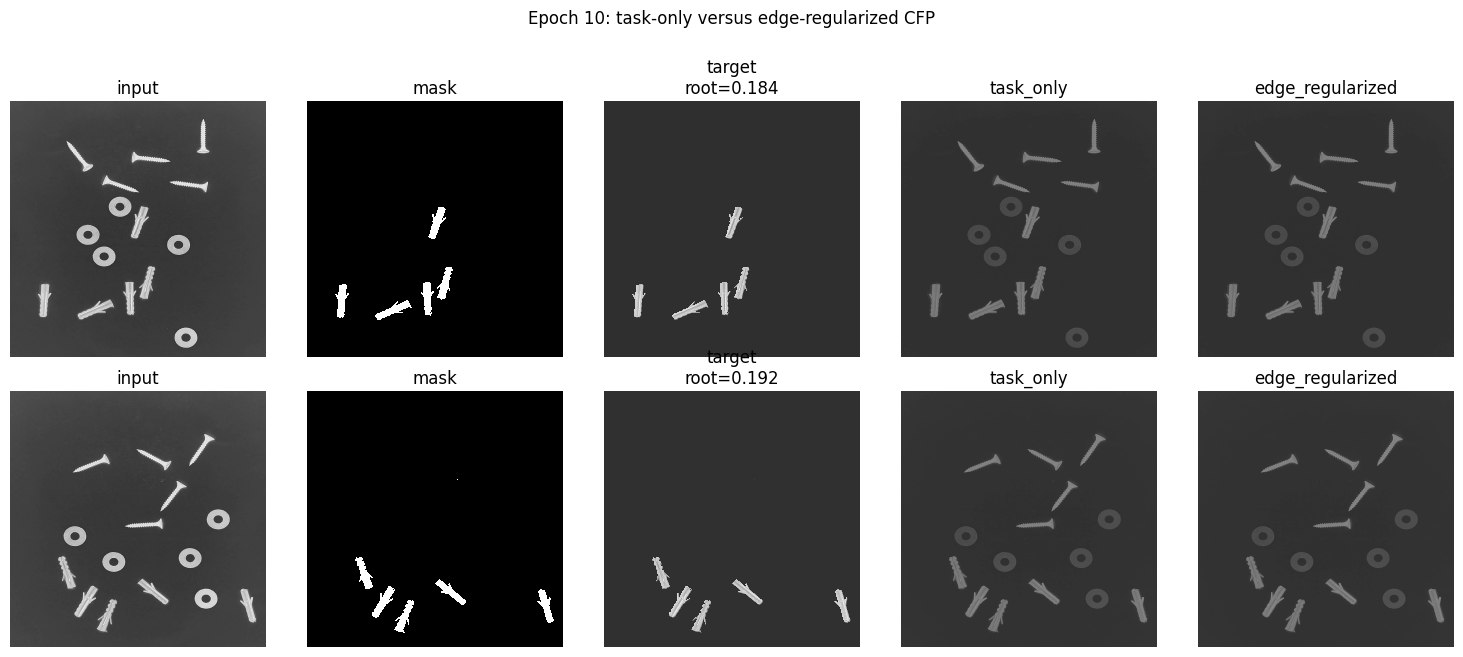

epoch 20


,epoch,split,layer,mse,mae,regularization_penalty,edge_violation_mean,edge_violation_mse,edge_violation_rate,max_edge_violation
0,20,train,task_only,0.002364,0.016645,0.000000,0.109402,0.050092,0.496007,0.794106
1,20,train,edge_regularized,0.002364,0.016646,0.005023,0.109392,0.050086,0.495752,0.794101


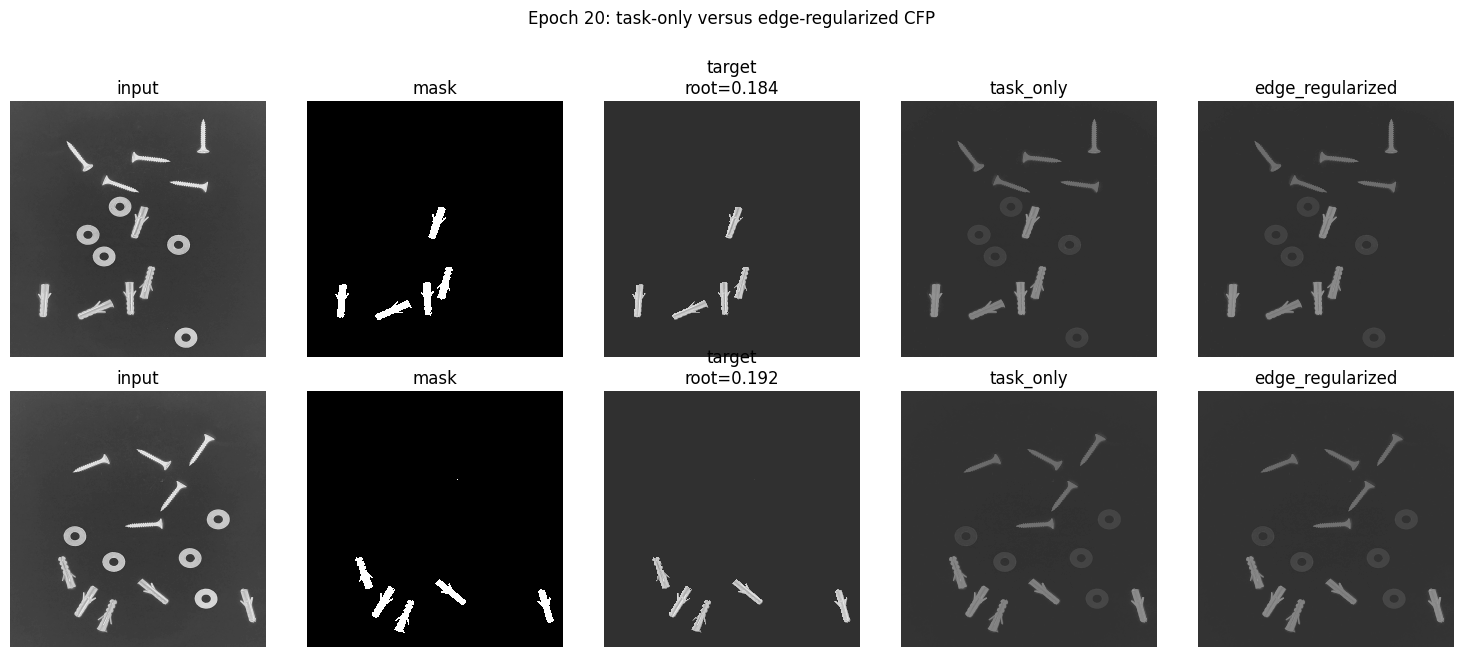

epoch 40


,epoch,split,layer,mse,mae,regularization_penalty,edge_violation_mean,edge_violation_mse,edge_violation_rate,max_edge_violation
0,40,train,task_only,0.001619,0.013185,0.000000,0.183062,0.116915,0.578386,0.979621
1,40,train,edge_regularized,0.001674,0.012785,0.010963,0.172167,0.109437,0.573086,0.969901


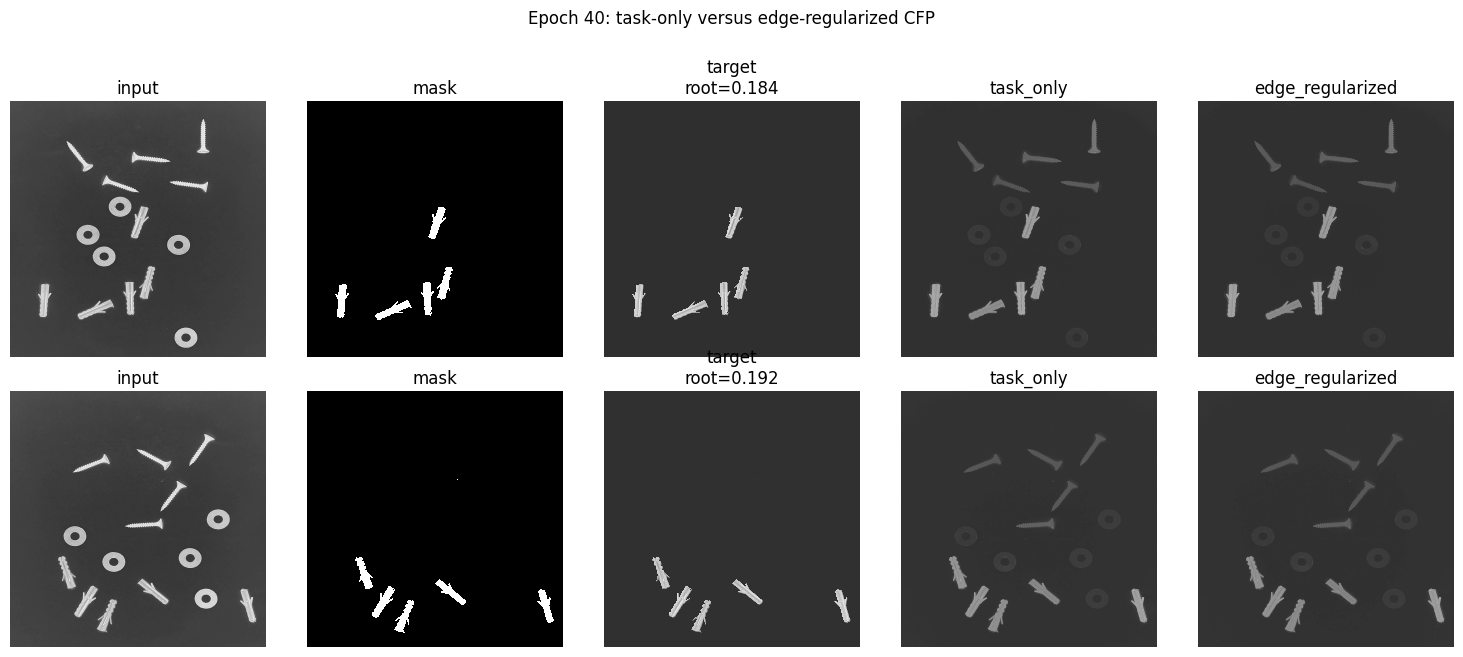

epoch 60


,epoch,split,layer,mse,mae,regularization_penalty,edge_violation_mean,edge_violation_mse,edge_violation_rate,max_edge_violation
0,60,train,task_only,0.001279,0.012083,0.000000,0.208505,0.143629,0.603712,0.996455
1,60,train,edge_regularized,0.001305,0.011296,0.013956,0.201523,0.139215,0.600348,0.995121


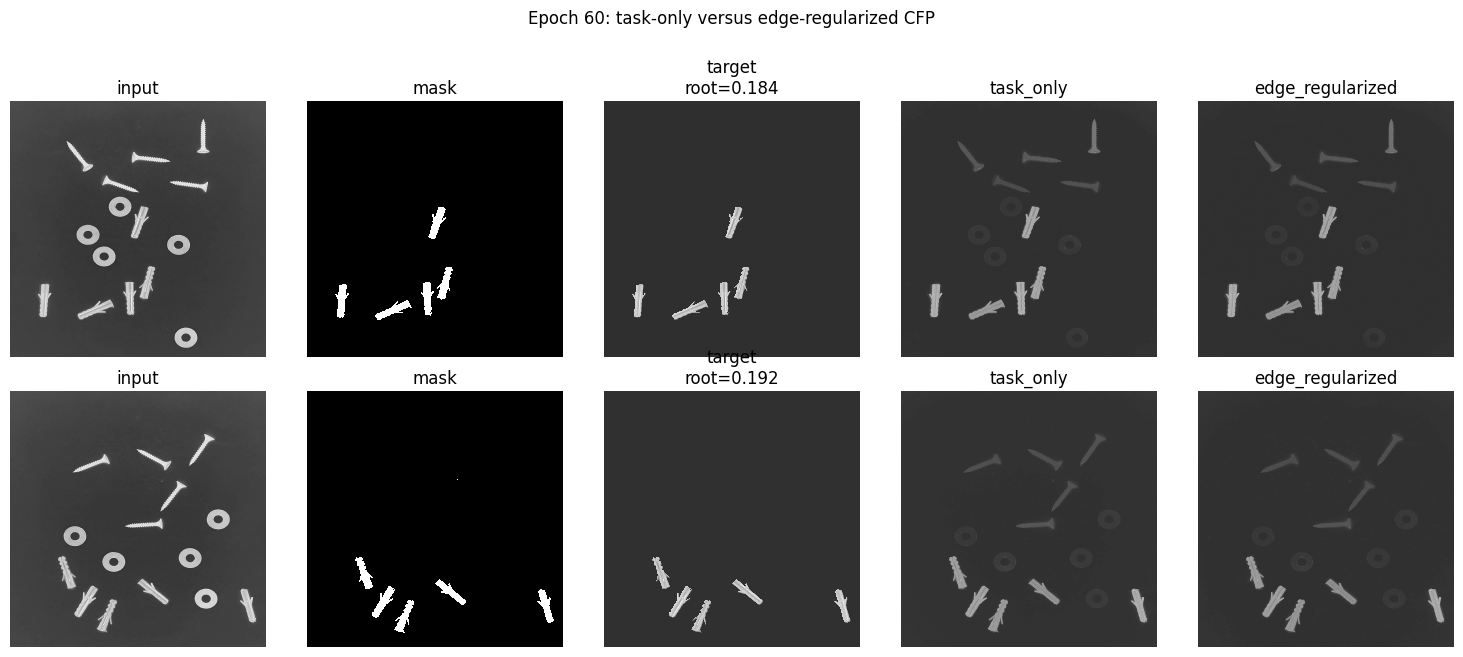

epoch 100


,epoch,split,layer,mse,mae,regularization_penalty,edge_violation_mean,edge_violation_mse,edge_violation_rate,max_edge_violation
0,100,train,task_only,0.000956,0.008872,0.000000,0.204096,0.156942,0.626172,0.999783
1,100,train,edge_regularized,0.000999,0.008998,0.015311,0.199236,0.152726,0.622646,0.999600


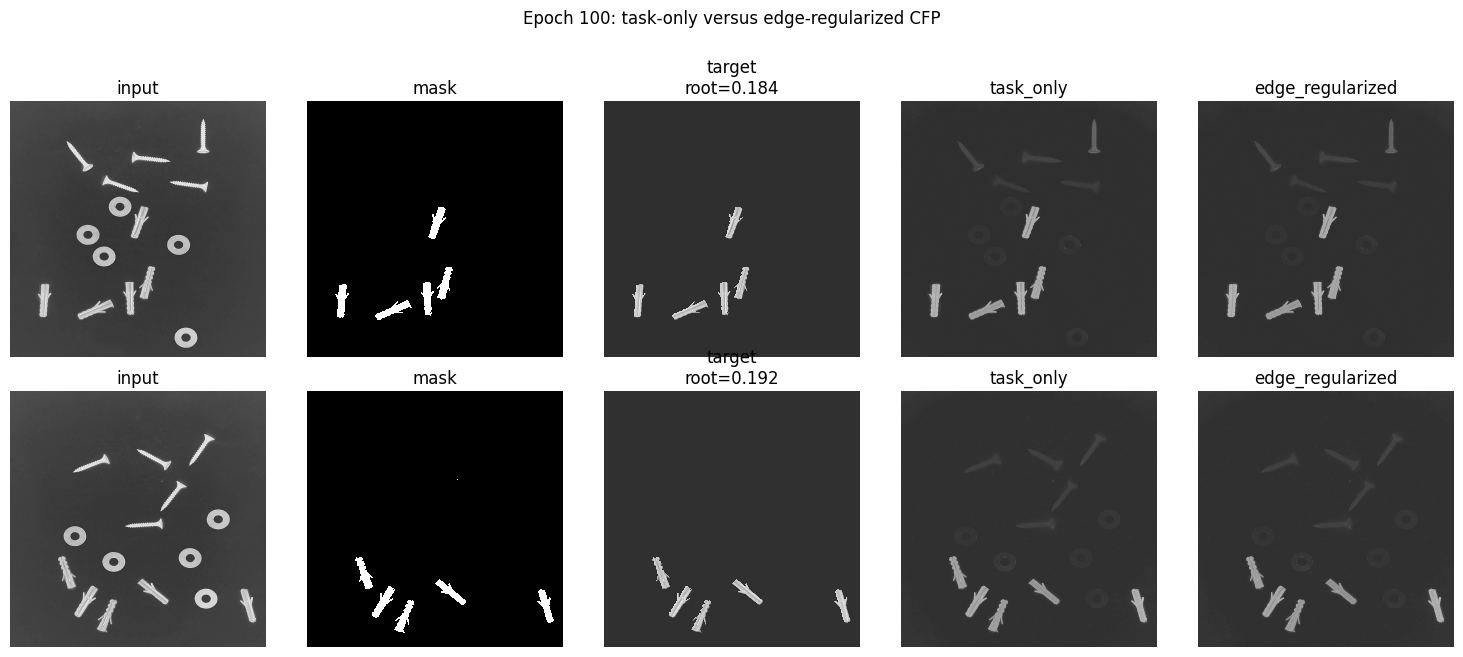

epoch 200


,epoch,split,layer,mse,mae,regularization_penalty,edge_violation_mean,edge_violation_mse,edge_violation_rate,max_edge_violation
0,200,train,task_only,0.000738,0.007316,0.000000,0.191514,0.163922,0.612648,0.999988
1,200,train,edge_regularized,0.000757,0.007266,0.016096,0.188632,0.160626,0.610265,0.999988


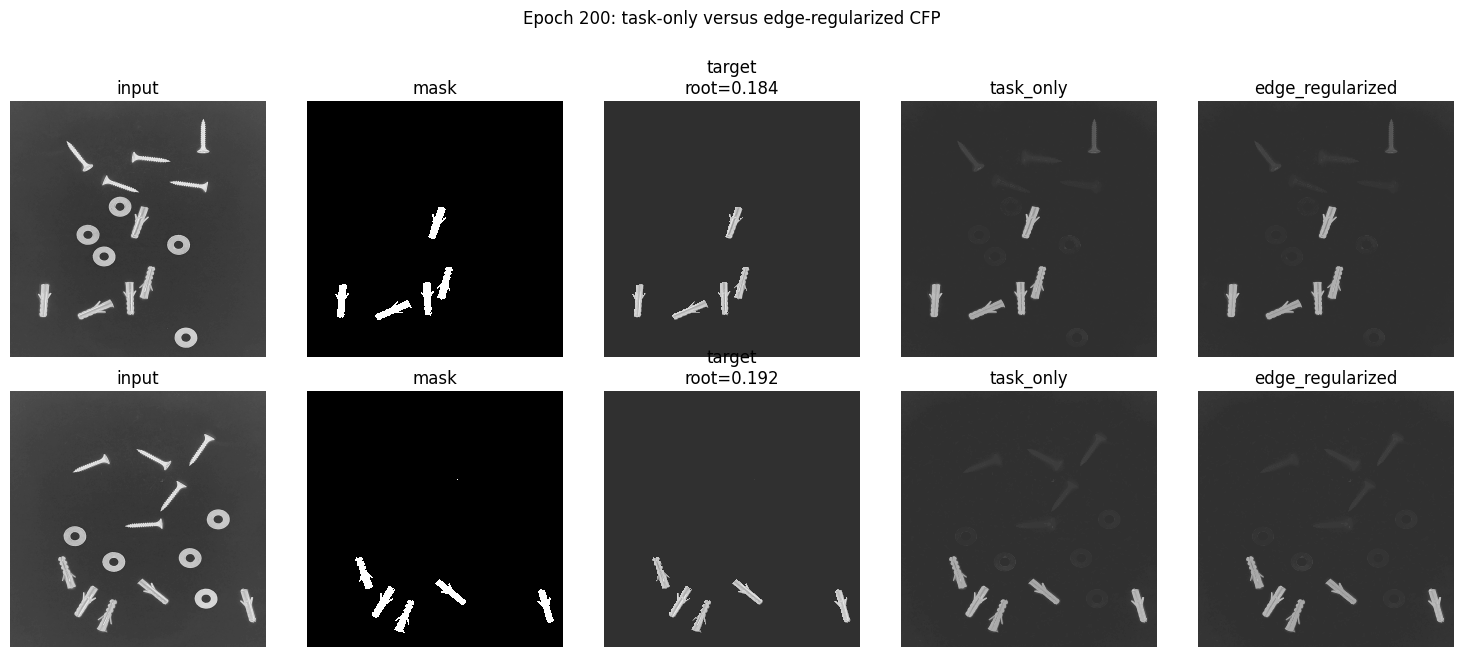

epoch 300


,epoch,split,layer,mse,mae,regularization_penalty,edge_violation_mean,edge_violation_mse,edge_violation_rate,max_edge_violation
0,300,train,task_only,0.000673,0.006316,0.000000,0.189334,0.168495,0.611448,0.999988
1,300,train,edge_regularized,0.000677,0.006325,0.016754,0.188186,0.167187,0.609087,0.999988


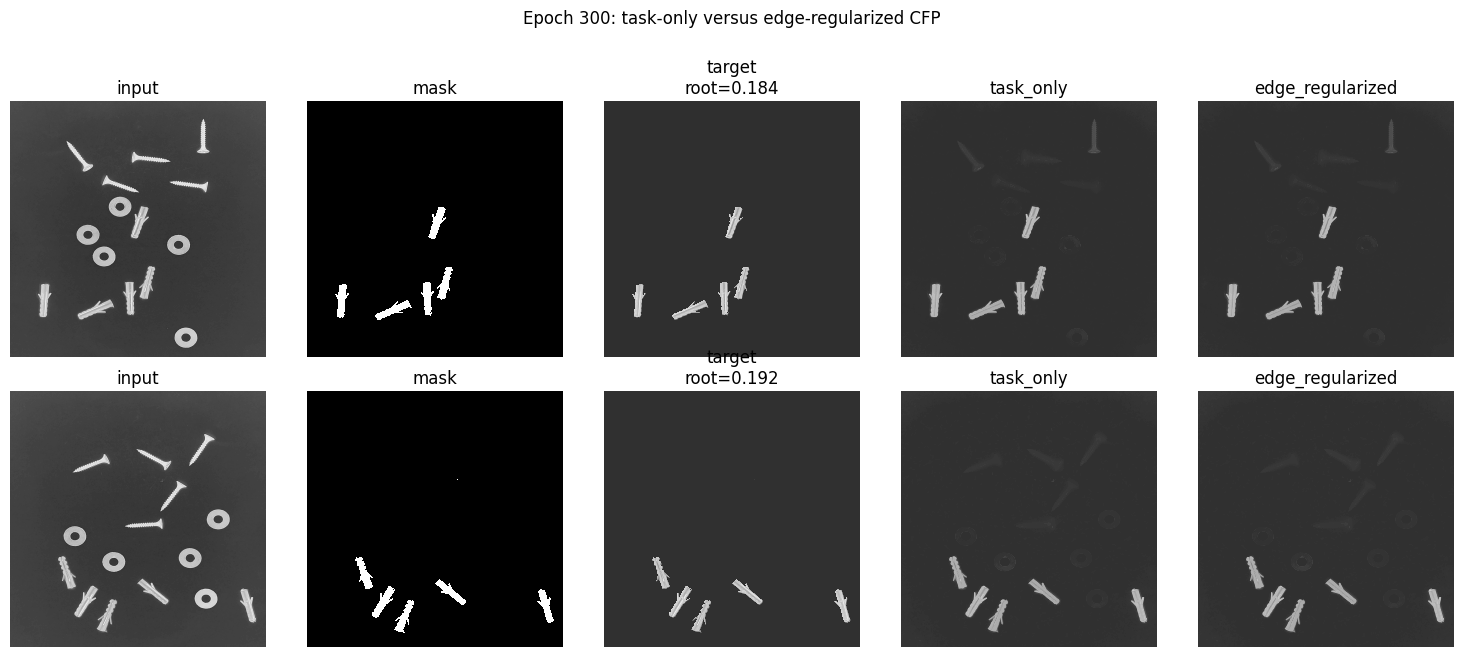

epoch 400


,epoch,split,layer,mse,mae,regularization_penalty,edge_violation_mean,edge_violation_mse,edge_violation_rate,max_edge_violation
0,400,train,task_only,0.000642,0.006004,0.00000,0.188782,0.171471,0.611169,0.999988
1,400,train,edge_regularized,0.000645,0.005952,0.01697,0.187278,0.169323,0.608519,0.999988


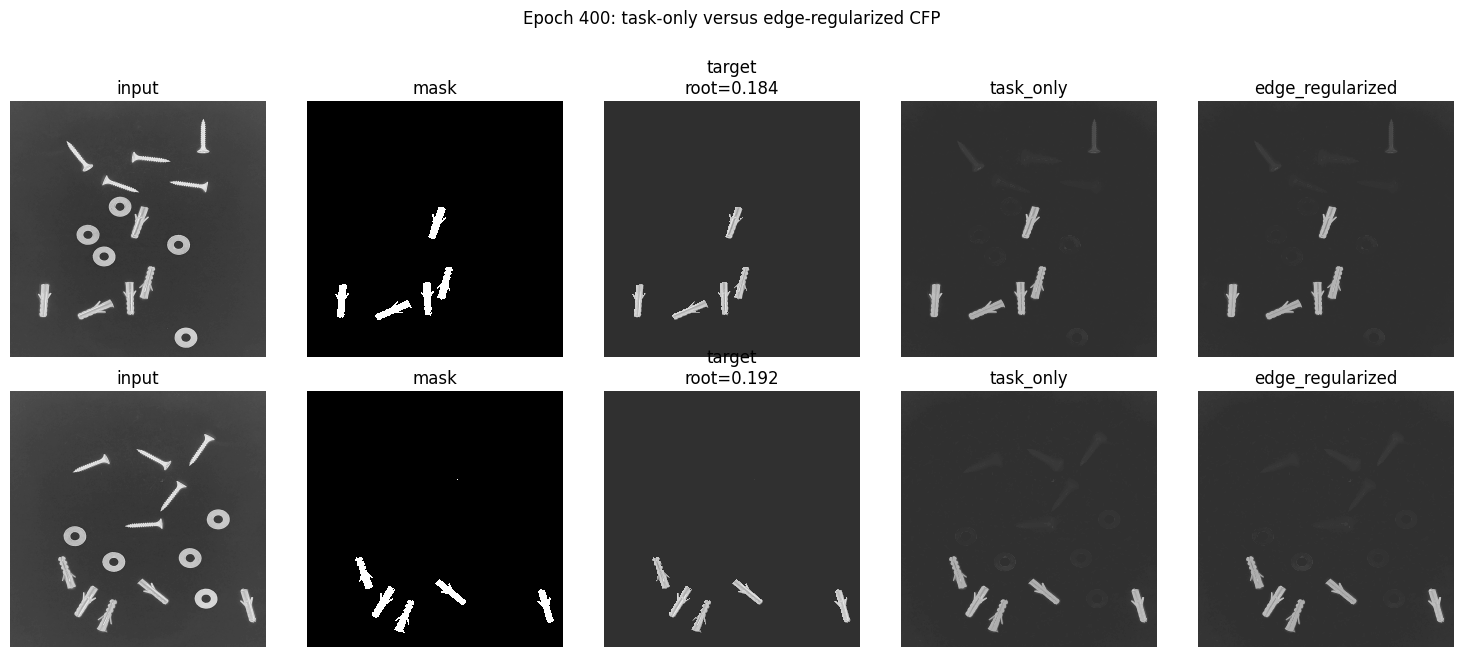

epoch 500


,epoch,split,layer,mse,mae,regularization_penalty,edge_violation_mean,edge_violation_mse,edge_violation_rate,max_edge_violation
0,500,train,task_only,0.000629,0.005677,0.000000,0.188889,0.173467,0.612329,0.999988
1,500,train,edge_regularized,0.000631,0.005661,0.017325,0.188528,0.172793,0.611686,0.999988


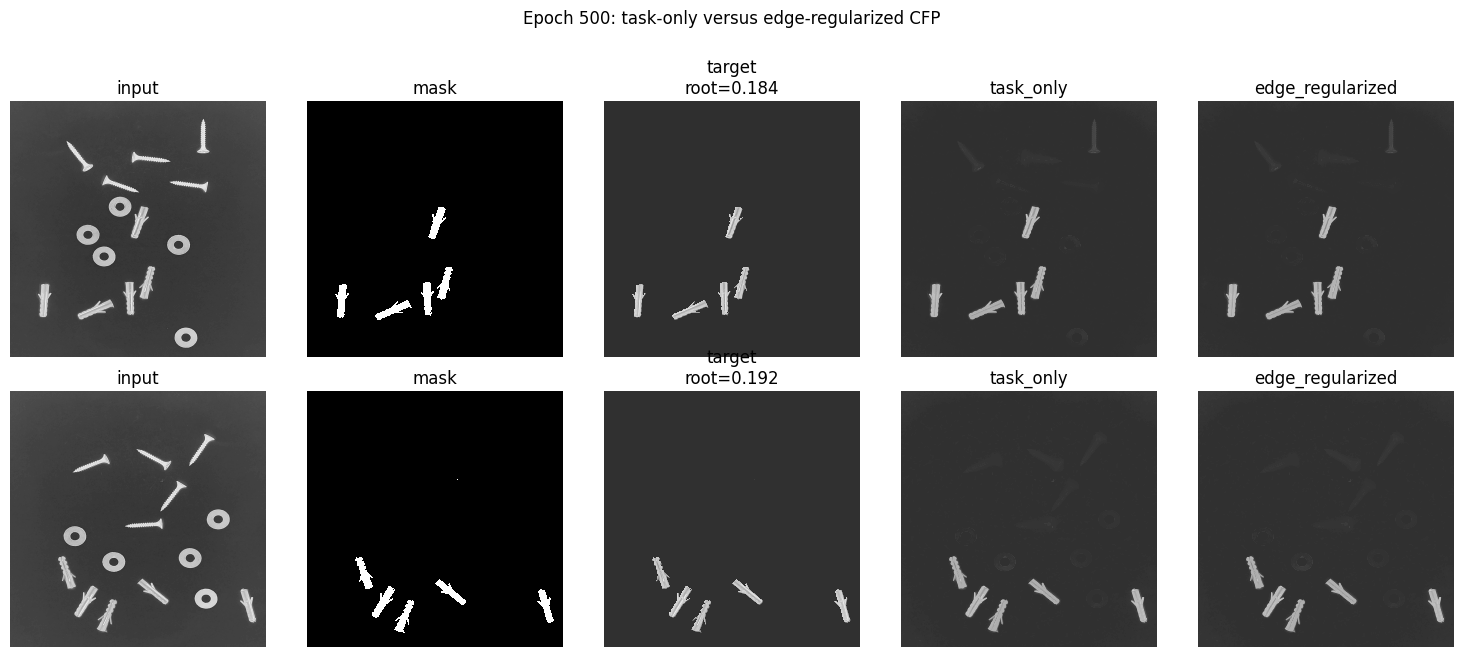

training completed in 3.937 minutes


In [14]:
mse_loss = nn.MSELoss(reduction="sum")
optimizers = {
    name: torch.optim.Adam(layer.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    for name, layer in layers.items()
}

report_rows = [initial_metrics]
objective_rows = []


def plot_report(epoch, loader):
    for layer in layers.values():
        layer.eval()
    batch = next(iter(loader))
    model_input, x, target, mask, root = split_precomputed_batch(batch)
    preds = {name: cfp_unit_output(layer, model_input) for name, layer in layers.items()}

    n = min(PLOT_SAMPLES, x.shape[0])
    fig, axes = plt.subplots(n, 5, figsize=(15, 3.2 * n), squeeze=False)
    fig.suptitle(f"Epoch {epoch}: task-only versus edge-regularized CFP", y=1.02)
    for row in range(n):
        panels = [
            (x[row, 0], "input"),
            (mask[row, 0], "mask"),
            (target[row, 0], f"target\nroot={float(root[row, 0, 0, 0]):.3f}"),
            (preds["task_only"][row, 0], "task_only"),
            (preds["edge_regularized"][row, 0], "edge_regularized"),
        ]
        for axis, (image, title) in zip(axes[row], panels):
            axis.imshow(image.detach().cpu(), cmap="gray", vmin=0.0, vmax=1.0)
            axis.set_title(title)
            axis.axis("off")
    plt.tight_layout()
    plt.show()


start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    for layer in layers.values():
        layer.train()

    running = {
        name: {"task_loss": 0.0, "regularization_penalty": 0.0, "count": 0}
        for name in layers
    }

    for batch in train_target_loader:
        model_input, _, target, _, _ = split_precomputed_batch(batch)
        batch_size = target.shape[0]

        for name, layer in layers.items():
            pred = cfp_unit_output(layer, model_input)
            task_loss = mse_loss(pred, target)
            regularization_loss = layer.regularization_penalty(model_input)
            loss = task_loss + regularization_loss

            optimizers[name].zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(layer.parameters(), max_norm=GRAD_CLIP)
            optimizers[name].step()

            running[name]["task_loss"] += float(task_loss.detach().cpu()) * batch_size
            running[name]["regularization_penalty"] += float(regularization_loss.detach().cpu()) * batch_size
            running[name]["count"] += batch_size

    for name, row in running.items():
        objective_rows.append(
            {
                "epoch": epoch,
                "layer": name,
                "task_loss": row["task_loss"] / max(row["count"], 1),
                "regularization_penalty": row["regularization_penalty"] / max(row["count"], 1),
            }
        )

    if epoch in REPORT_EPOCHS:
        train_metrics = evaluate(eval_train_target_loader)
        train_metrics.insert(0, "epoch", epoch)
        train_metrics.insert(1, "split", "train")
        test_metrics = evaluate(test_target_loader)
        test_metrics.insert(0, "epoch", epoch)
        test_metrics.insert(1, "split", "test")
        report_rows.extend([train_metrics, test_metrics])

        print(f"epoch {epoch}")
        display(train_metrics)
        plot_report(epoch, plot_target_loader)

elapsed_minutes = (time.time() - start) / 60.0
print(f"training completed in {elapsed_minutes:.3f} minutes")


## Results

The reconstruction curves show the task fit. The violation curves show whether the score field is becoming more consistent along parent-child tree edges.


,epoch,split,layer,mse,regularization_penalty,edge_violation_mse,edge_violation_rate,max_edge_violation
1,0,train,edge_regularized,0.013377,0.000000,0.000000,0.000000,0.000000
0,0,train,task_only,0.013377,0.000000,0.000000,0.000000,0.000000
5,1,test,edge_regularized,0.006901,0.000754,0.007545,0.748403,0.197189
4,1,test,task_only,0.006901,0.000000,0.007545,0.748403,0.197189
3,1,train,edge_regularized,0.006787,0.000748,0.007486,0.747859,0.199300
2,1,train,task_only,0.006787,0.000000,0.007486,0.747859,0.199300
9,5,test,edge_regularized,0.004382,0.001902,0.019042,0.763616,0.258984
8,5,test,task_only,0.004382,0.000000,0.019043,0.763643,0.258987
7,5,train,edge_regularized,0.004350,0.001891,0.018931,0.763418,0.264435
6,5,train,task_only,0.004350,0.000000,0.018931,0.763407,0.264437


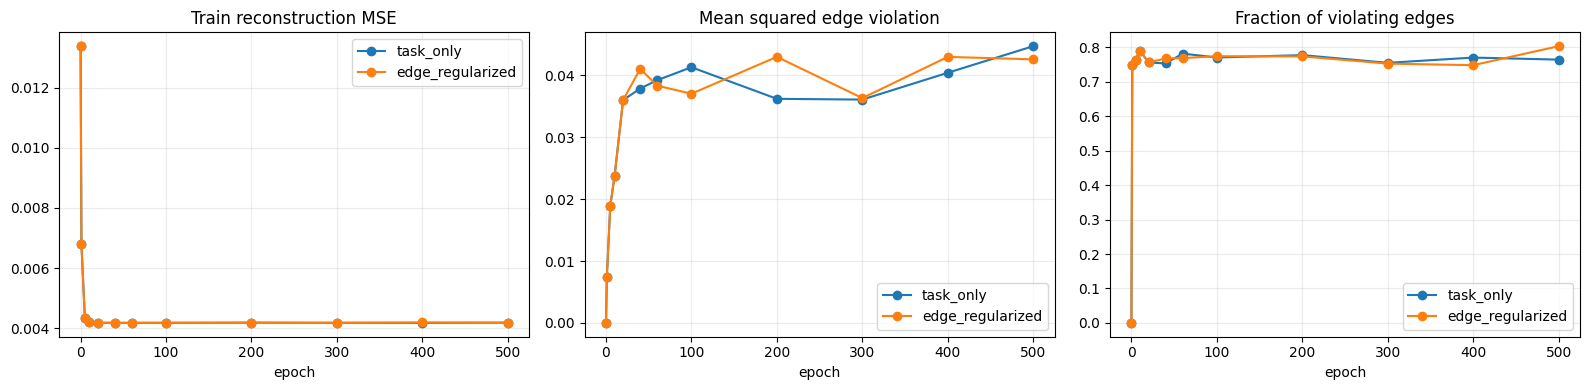

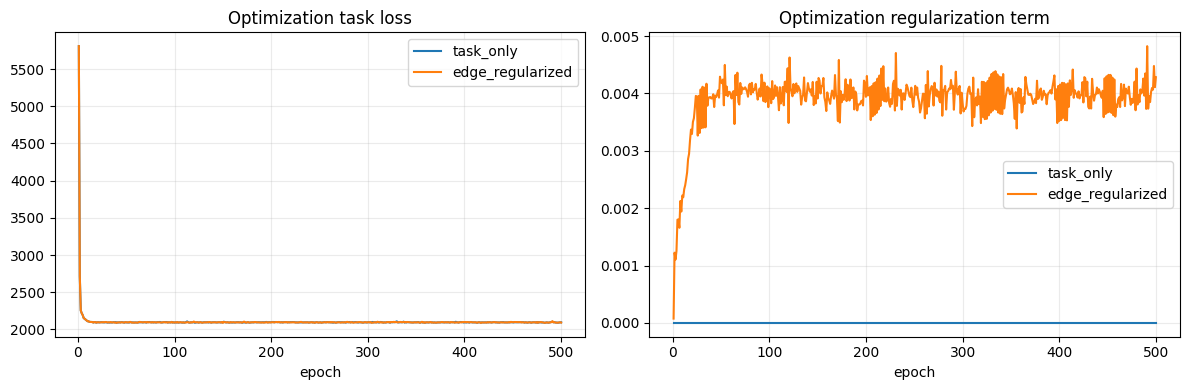

In [8]:
reports = pd.concat(report_rows, ignore_index=True)
objectives = pd.DataFrame(objective_rows)

display_columns = [
    "epoch",
    "split",
    "layer",
    "mse",
    "regularization_penalty",
    "edge_violation_mse",
    "edge_violation_rate",
    "max_edge_violation",
]
display(reports[display_columns].sort_values(["epoch", "split", "layer"]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
train_reports = reports[reports["split"] == "train"]
for layer_name in layers:
    layer_rows = train_reports[train_reports["layer"] == layer_name]
    axes[0].plot(layer_rows["epoch"], layer_rows["mse"], marker="o", label=layer_name)
    axes[1].plot(layer_rows["epoch"], layer_rows["edge_violation_mse"], marker="o", label=layer_name)
    axes[2].plot(layer_rows["epoch"], layer_rows["edge_violation_rate"], marker="o", label=layer_name)

axes[0].set_title("Train reconstruction MSE")
axes[1].set_title("Mean squared edge violation")
axes[2].set_title("Fraction of violating edges")
for axis in axes:
    axis.set_xlabel("epoch")
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for layer_name in layers:
    layer_rows = objectives[objectives["layer"] == layer_name]
    axes[0].plot(layer_rows["epoch"], layer_rows["task_loss"], label=layer_name)
    axes[1].plot(layer_rows["epoch"], layer_rows["regularization_penalty"], label=layer_name)
axes[0].set_title("Optimization task loss")
axes[1].set_title("Optimization regularization term")
for axis in axes:
    axis.set_xlabel("epoch")
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()


## Design note

This notebook uses `edge_score_monotonicity` as a simple example of CFP regularization. The regularizer does not replace the task loss and does not run automatically inside `forward(...)`; the training loop must add `layer.regularization_penalty(model_input)` explicitly.

The regularizer observes post-constraint scores. Since both layers use the `preserve_root` constraint, root scores are fixed before the edge regularizer evaluates parent-child violations. Other built-in regularizers, such as `attribute_order_score_monotonicity` and `path_score_monotonicity`, use the same `regularization_penalty(...)` entry point but encode different structural preferences.
